<a href="https://colab.research.google.com/github/avishi0229/herpes_zoster_btp/blob/main/notebooks/explanation_system_btp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/avishi0229/herpes_zoster_btp/blob/main/explanation_system_btp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explanation System: Multimodal XAI for Herpes Zoster Detection
**Part of:** *A Multimodal Explainable AI Framework for Herpes Zoster Detection* (7th-Semester B.Tech Project)

## Objective

The three upstream notebooks (`clinical_model_btp.ipynb`, `image_model_btp.ipynb`, `multimodal_fusion_btp.ipynb`)
train the clinical branch, the image branch, and the fusion classifier, and already produce basic
Grad-CAM examples for the image branch. **This notebook does not retrain the pipeline** — it is a
dedicated **explanation layer** on top of the already-fixed 78/17/17 case-level split, and answers,
**for any individual case**, two questions at once:

1. **Image:** *which part of the lesion image* pushed the model toward (or away from) an HZ prediction —
   via **Grad-CAM** on the ResNet50 image branch, plus a simple heatmap-localisation summary (which
   quadrant / region of the image is most activated).
2. **Clinical:** *which reported symptoms, body part, texture, and demographic fields* pushed the model
   toward (or away from) an HZ prediction — via **signed feature-contribution analysis** on the clinical
   Logistic Regression baseline (coefficient × value, in the model's own probability units) and
   **Integrated Gradients** on the clinical MLP encoder, for cross-checking.
3. **Fusion:** how much of the *final* multimodal decision is attributable to the **image modality**
   vs. the **clinical modality** for that specific case — via **modality-ablation** (replacing one
   modality's embedding with its training-set mean) and **Integrated Gradients** on the fused 2064-D
   vector, aggregated per modality.

Everything is combined into one **per-case explanation dashboard** (image + heatmap, clinical feature
bars, modality-contribution bars, and the final prediction), saved under `outputs/explanations/`.

**Rules followed, consistent with the rest of the project:**
- The existing case-level split (`data/processed/{train,validation,test}.csv`) is used as-is — no new
  split is created here.
- No dataset file and no existing notebook/script in the repo is modified.
- If the trained artifacts from the upstream notebooks already exist under `outputs/`, they are loaded
  as-is. If any are missing (e.g. a fresh clone/Colab session where only `outputs/*/embeddings` and
  `outputs/fusion/` were committed), this notebook **reproduces them using the identical procedure**
  (same architecture, hyperparameters, and seed) so the explanation pipeline is fully self-contained.
- Explanations are generated **only for the test set** (never used for any training decision) plus,
  optionally, any case_id you pass in yourself.
- This is a **research / decision-support prototype**. Grad-CAM and feature-attribution outputs are
  visual/quantitative aids that describe *what the model responded to*, not a clinical diagnosis, and
  they do not prove the model is using clinically meaningful features.

## 0. Setup

Clones the repo if it isn't already present (so this notebook can be opened standalone in Colab),
then imports libraries and fixes the seed. `torch`, `scikit-learn`, `pandas`, `numpy`, `joblib`,
`matplotlib`, and `Pillow` are preinstalled in Colab — no package installation is run here (an
unpinned `pip install --upgrade` can silently change library versions between runs, which is a
reproducibility risk we avoid, matching the other notebooks in this repo).

In [1]:
import os, subprocess

REPO_URL = "https://github.com/avishi0229/herpes_zoster_btp.git"
REPO_DIR = "herpes_zoster_btp"

# If we are not already inside a clone of the repo (i.e. running fresh in Colab),
# clone it. If you already have the repo mounted/uploaded with this notebook sitting
# next to `data/`, `notebooks/`, `outputs/`, `scripts/`, this cell does nothing.
if not (os.path.isdir("data") and os.path.isdir("notebooks")):
    if not os.path.isdir(REPO_DIR):
        print("Cloning repository ...")
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working directory:", os.getcwd())
assert os.path.isdir("data") and os.path.isdir("outputs"), "Repo root not found as expected."

Cloning repository ...
Working directory: /content/herpes_zoster_btp


In [2]:
import json
import random
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)
from torchvision import models, transforms
import joblib

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

REPO = Path(".")
IMG_DIR = REPO / "data" / "images"
IMG_SIZE = 224

OUT_CLINICAL = REPO / "outputs" / "clinical"
OUT_IMAGE = REPO / "outputs" / "image"
OUT_FUSION = REPO / "outputs" / "fusion"
OUT_EXPL = REPO / "outputs" / "explanations"
for d in [OUT_CLINICAL / "models", OUT_IMAGE, OUT_IMAGE / "embeddings", OUT_FUSION / "models",
          OUT_EXPL, OUT_EXPL / "cases"]:
    d.mkdir(parents=True, exist_ok=True)

print("Image dir exists:", IMG_DIR.exists())

Device: cpu
Image dir exists: True


## 1. Load the fixed case-level split

Loads `train.csv` / `validation.csv` / `test.csv` exactly as the other notebooks do, with the same
leakage/uniqueness assertions. **This notebook only ever generates explanations for the test split**
(and any ad-hoc `case_id` you look up yourself), so nothing here can leak into model training.

In [25]:
TRAIN_PATH = REPO / "data/processed/train.csv"
VAL_PATH   = REPO / "data/processed/validation.csv"
TEST_PATH  = REPO / "data/processed/test.csv"

train_df = pd.read_csv(TRAIN_PATH, dtype={'case_id': 'int64'})
val_df   = pd.read_csv(VAL_PATH, dtype={'case_id': 'int64'})
test_df  = pd.read_csv(TEST_PATH, dtype={'case_id': 'int64'})

for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    assert df["case_id"].nunique() == len(df), f"Duplicate case_id in {name}!"

train_ids, val_ids, test_ids = set(train_df.case_id), set(val_df.case_id), set(test_df.case_id)
assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids), "Split leakage!"

print("Train:", train_df.shape, "| Validation:", val_df.shape, "| Test:", test_df.shape)
print("Test label balance:", test_df["label"].value_counts().to_dict())

Train: (78, 31) | Validation: (17, 31) | Test: (17, 31)
Test label balance: {0: 9, 1: 8}


## 2. Clinical branch — load or rebuild

Identical feature handling to `clinical_model_btp.ipynb`:
- `other_symptoms_fever` is dropped (100% missing in training data).
- 4 categorical columns → `OneHotEncoder(handle_unknown="ignore")`, fit on **train only**.
- 19 binary presence flags → deterministic `"YES" -> 1` mapping.
- Combined feature matrix scaled with `StandardScaler`, fit on **train only**.
- A small MLP (`Linear(in,32) -> ReLU -> Dropout(0.3) -> Linear(32,16) -> ReLU -> Linear(16,1)`) is the
  clinical encoder/classifier used for embeddings and predictions.

If `outputs/clinical/models/*.joblib` / `*.pt` already exist (from running `clinical_model_btp.ipynb`),
they are loaded directly. Otherwise they are refit here, from `train_df` / `val_df` only, using the
same seed and hyperparameters — this takes a few seconds on CPU.

In [4]:
CATEGORICAL_COLS = ["age_group", "sex_at_birth", "fitzpatrick_skin_type", "condition_duration"]
BINARY_FLAG_COLS = [
    "textures_raised_or_bumpy", "textures_flat", "textures_rough_or_flaky", "textures_fluid_filled",
    "body_parts_head_or_neck", "body_parts_arm", "body_parts_palm", "body_parts_back_of_hand",
    "body_parts_torso_front", "body_parts_torso_back", "body_parts_buttocks", "body_parts_leg",
    "body_parts_foot_top_or_side", "body_parts_foot_sole",
    "condition_symptoms_itching", "condition_symptoms_burning", "condition_symptoms_pain",
    "other_symptoms_chills", "other_symptoms_fatigue",
]
DROPPED_COLS = ["other_symptoms_fever"]

def encode_binary_flags(df, cols):
    out = pd.DataFrame(index=df.index)
    for c in cols:
        out[c] = (df[c].astype(str).str.upper() == "YES").astype(int)
    return out

def prep_categorical(df, cols):
    out = df[cols].copy()
    for c in cols:
        out[c] = out[c].astype(str).where(out[c].notna(), "MISSING")
        out[c] = out[c].replace("nan", "MISSING")
    return out

CLIN_MODELS_DIR = OUT_CLINICAL / "models"
ohe_path, scaler_path, logreg_path, encoder_path = (
    CLIN_MODELS_DIR / "onehot_encoder.joblib",
    CLIN_MODELS_DIR / "feature_scaler.joblib",
    CLIN_MODELS_DIR / "baseline_logreg.joblib",
    CLIN_MODELS_DIR / "clinical_encoder_state_dict.pt",
)

class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, embed_dim=16, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.ReLU(),
        )
        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, x):
        embedding = self.encoder(x)
        logit = self.classifier(embedding).squeeze(-1)
        return logit, embedding

train_bin = encode_binary_flags(train_df, BINARY_FLAG_COLS)
val_bin   = encode_binary_flags(val_df, BINARY_FLAG_COLS)
test_bin  = encode_binary_flags(test_df, BINARY_FLAG_COLS)

train_cat_raw = prep_categorical(train_df, CATEGORICAL_COLS)
val_cat_raw   = prep_categorical(val_df, CATEGORICAL_COLS)
test_cat_raw  = prep_categorical(test_df, CATEGORICAL_COLS)

if ohe_path.exists() and scaler_path.exists() and logreg_path.exists() and encoder_path.exists():
    print("Loading saved clinical artifacts from", CLIN_MODELS_DIR)
    ohe = joblib.load(ohe_path)
    scaler = joblib.load(scaler_path)
    baseline_clf = joblib.load(logreg_path)
    REFIT_CLINICAL = False
else:
    print("Saved clinical artifacts not found -- refitting from train/validation (same procedure as "
          "clinical_model_btp.ipynb).")
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe.fit(train_cat_raw)
    REFIT_CLINICAL = True

ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_COLS)
train_cat = pd.DataFrame(ohe.transform(train_cat_raw), columns=ohe_feature_names, index=train_df.index)
val_cat   = pd.DataFrame(ohe.transform(val_cat_raw),   columns=ohe_feature_names, index=val_df.index)
test_cat  = pd.DataFrame(ohe.transform(test_cat_raw),  columns=ohe_feature_names, index=test_df.index)

CLIN_FEATURE_NAMES = list(train_cat.columns) + list(train_bin.columns)

X_train_raw = pd.concat([train_cat, train_bin], axis=1)[CLIN_FEATURE_NAMES].to_numpy(dtype=np.float32)
X_val_raw   = pd.concat([val_cat,   val_bin],   axis=1)[CLIN_FEATURE_NAMES].to_numpy(dtype=np.float32)
X_test_raw  = pd.concat([test_cat,  test_bin],  axis=1)[CLIN_FEATURE_NAMES].to_numpy(dtype=np.float32)

if REFIT_CLINICAL:
    scaler = StandardScaler().fit(X_train_raw)

X_train_clin = scaler.transform(X_train_raw)
X_val_clin   = scaler.transform(X_val_raw)
X_test_clin  = scaler.transform(X_test_raw)

y_train = train_df["label"].to_numpy()
y_val   = val_df["label"].to_numpy()
y_test  = test_df["label"].to_numpy()

if REFIT_CLINICAL:
    baseline_clf = LogisticRegression(C=0.5, penalty="l2", class_weight="balanced",
                                       max_iter=1000, random_state=SEED)
    baseline_clf.fit(X_train_clin, y_train)

print(f"Clinical feature matrix: {X_train_clin.shape[1]} features "
      f"({len(ohe_feature_names)} one-hot + {len(BINARY_FLAG_COLS)} binary).")

Saved clinical artifacts not found -- refitting from train/validation (same procedure as clinical_model_btp.ipynb).
Clinical feature matrix: 45 features (26 one-hot + 19 binary).


In [5]:
INPUT_DIM = X_train_clin.shape[1]
clinical_model = ClinicalEncoder(INPUT_DIM).to(DEVICE)

if not REFIT_CLINICAL:
    clinical_model.load_state_dict(torch.load(encoder_path, map_location=DEVICE))
else:
    X_train_t = torch.tensor(X_train_clin, dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
    X_val_t   = torch.tensor(X_val_clin, dtype=torch.float32).to(DEVICE)
    y_val_t   = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    optimizer = torch.optim.Adam(clinical_model.parameters(), lr=1e-3, weight_decay=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss, best_state, patience, bad = float("inf"), None, 20, 0
    for epoch in range(1, 201):
        clinical_model.train(); optimizer.zero_grad()
        logits, _ = clinical_model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward(); optimizer.step()

        clinical_model.eval()
        with torch.no_grad():
            val_logits, _ = clinical_model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss, best_state, bad = val_loss, {k: v.clone() for k, v in clinical_model.state_dict().items()}, 0
        else:
            bad += 1
        if bad >= patience:
            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break
    clinical_model.load_state_dict(best_state)

    # Persist so subsequent runs (and other notebooks reading outputs/) can reuse this exact model.
    ohe_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(ohe, ohe_path)
    joblib.dump(scaler, scaler_path)
    joblib.dump(baseline_clf, logreg_path)
    torch.save(clinical_model.state_dict(), encoder_path)
    print("Refitted clinical artifacts saved to", CLIN_MODELS_DIR)

clinical_model.eval()

@torch.no_grad()
def clinical_predict_proba(X):
    X_t = torch.tensor(np.asarray(X), dtype=torch.float32).to(DEVICE)
    logits, embedding = clinical_model(X_t)
    return torch.sigmoid(logits).cpu().numpy(), embedding.cpu().numpy()

val_prob, _ = clinical_predict_proba(X_val_clin)
val_auc = roc_auc_score(y_val, val_prob) if len(set(y_val)) > 1 else float("nan")
print(f"Clinical encoder sanity check -- validation ROC-AUC: {val_auc:.3f}")

Early stopping at epoch 99 (best val_loss=0.6758)
Refitted clinical artifacts saved to outputs/clinical/models
Clinical encoder sanity check -- validation ROC-AUC: 0.542


## 3. Image branch — load or rebuild (ResNet50)

Identical architecture to `image_model_btp.ipynb`: pretrained ResNet50 backbone (`IMAGENET1K_V2`)
with `backbone.fc = Identity()` so `get_embedding()` returns the 2048-D pre-classification vector,
and a single-logit linear classifier on top. Phase 1 trains only the classifier head (backbone frozen);
Phase 2 optionally fine-tunes `layer4` at a low learning rate. Model selection uses **validation loss
only**; the checkpoint with the lowest validation loss is kept.

If `outputs/image/best_resnet50.pth` already exists, it is loaded directly (instant). Otherwise this
cell **retrains it here** using the identical procedure and hyperparameters — recommended: `Runtime >
Change runtime type > T4 GPU` first; expect roughly 5-10 minutes on a T4.

In [6]:
IMG_COLS = [c for c in train_df.columns if c.startswith("image_") and c.endswith("_path")]

def to_image_level(df):
    rows = []
    for _, r in df.iterrows():
        for c in IMG_COLS:
            if pd.notna(r[c]):
                rows.append({"case_id": r["case_id"], "label": int(r["label"]), "condition": r["condition"],
                             "path": str(IMG_DIR / os.path.basename(r[c]))})
    return pd.DataFrame(rows)

img_data = {"train": to_image_level(train_df), "validation": to_image_level(val_df), "test": to_image_level(test_df)}
for split, d in img_data.items():
    missing = [p for p in d.path if not os.path.exists(p)]
    assert not missing, f"{split}: {len(missing)} image file(s) not found under {IMG_DIR}"
    print(f"{split:11s} cases={d.case_id.nunique():3d} images={len(d):3d}")

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
eval_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
                               transforms.Normalize(MEAN, STD)])
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class SkinDataset(Dataset):
    def __init__(self, df, tf): self.df, self.tf = df.reset_index(drop=True), tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        x = self.tf(Image.open(r.path).convert("RGB"))
        return x, torch.tensor(r.label, dtype=torch.float32), r.case_id, r.path

def make_img_loader(split, tf, shuffle, batch_size=16):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(SkinDataset(img_data[split], tf), batch_size=batch_size, shuffle=shuffle, generator=g)

class HZImageModel(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.emb_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(self.emb_dim, 1))
    def get_embedding(self, x): return self.backbone(x)
    def forward(self, x): return self.classifier(self.get_embedding(x)).squeeze(1)

def set_trainable(model, phase):
    for p in model.parameters(): p.requires_grad = False
    for p in model.classifier.parameters(): p.requires_grad = True
    if phase == 2:
        for p in model.backbone.layer4.parameters(): p.requires_grad = True

def set_mode(model, phase):
    model.train()
    if phase == 1: model.backbone.eval()
    else:
        for n, m in model.backbone.named_modules():
            if isinstance(m, nn.BatchNorm2d) and not n.startswith("layer4"): m.eval()

set_seed()
image_model = HZImageModel().to(DEVICE)
IMG_CKPT = OUT_IMAGE / "best_resnet50.pth"

train       cases= 78 images=155
validation  cases= 17 images= 35
test        cases= 17 images= 33
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s]


In [7]:
if IMG_CKPT.exists():
    print("Loading saved image checkpoint from", IMG_CKPT)
    image_model.load_state_dict(torch.load(IMG_CKPT, map_location=DEVICE))
else:
    print("Saved image checkpoint not found -- retraining ResNet50 here (same procedure as "
          "image_model_btp.ipynb). This may take several minutes.")
    train_loader = make_img_loader("train", train_tf, True)
    val_loader   = make_img_loader("validation", eval_tf, False)
    criterion = nn.BCEWithLogitsLoss()

    def run_epoch(model, loader, optimizer=None, phase=1):
        train = optimizer is not None
        if train: set_mode(model, phase)
        else: model.eval()
        tot_loss, correct, n = 0.0, 0, 0
        with torch.set_grad_enabled(train):
            for x, y, _, _ in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x); loss = criterion(logits, y)
                if train: optimizer.zero_grad(); loss.backward(); optimizer.step()
                tot_loss += loss.item() * len(y)
                correct += ((torch.sigmoid(logits) > 0.5).float() == y).sum().item(); n += len(y)
        return tot_loss / n, correct / n

    best = {"val_loss": float("inf"), "state": None, "epoch": -1}

    def fit(phase, epochs, lr_head, lr_backbone=None, patience=6):
        set_trainable(image_model, phase)
        groups = [{"params": image_model.classifier.parameters(), "lr": lr_head}]
        if phase == 2: groups.append({"params": image_model.backbone.layer4.parameters(), "lr": lr_backbone})
        opt = torch.optim.AdamW(groups, weight_decay=1e-2)
        bad = 0
        for ep in range(1, epochs + 1):
            tl, ta = run_epoch(image_model, train_loader, opt, phase)
            vl, va = run_epoch(image_model, val_loader)
            flag = ""
            if vl < best["val_loss"]:
                best.update(val_loss=vl, state=copy.deepcopy(image_model.state_dict()), epoch=ep)
                torch.save(best["state"], IMG_CKPT); flag = " *best*"; bad = 0
            else:
                bad += 1
            if ep == 1 or ep % 5 == 0 or flag:
                print(f"P{phase} ep{ep:02d} | train loss {tl:.4f} acc {ta:.3f} | val loss {vl:.4f} acc {va:.3f}{flag}")
            if bad >= patience:
                print("Early stopping"); break

    fit(phase=1, epochs=20, lr_head=1e-3)
    image_model.load_state_dict(best["state"])
    fit(phase=2, epochs=20, lr_head=1e-4, lr_backbone=1e-5)
    image_model.load_state_dict(torch.load(IMG_CKPT, map_location=DEVICE))
    print("Best epoch:", best["epoch"], "| val loss:", round(best["val_loss"], 4))

image_model.eval()
print("Image model ready.")

Saved image checkpoint not found -- retraining ResNet50 here (same procedure as image_model_btp.ipynb). This may take several minutes.
P1 ep01 | train loss 0.7033 acc 0.542 | val loss 0.6842 acc 0.571 *best*
P1 ep02 | train loss 0.6322 acc 0.665 | val loss 0.6464 acc 0.629 *best*
P1 ep03 | train loss 0.5937 acc 0.742 | val loss 0.6167 acc 0.714 *best*
P1 ep04 | train loss 0.5742 acc 0.729 | val loss 0.5887 acc 0.686 *best*
P1 ep05 | train loss 0.5453 acc 0.781 | val loss 0.5838 acc 0.743 *best*
P1 ep06 | train loss 0.5158 acc 0.774 | val loss 0.5638 acc 0.714 *best*
P1 ep07 | train loss 0.5026 acc 0.800 | val loss 0.5549 acc 0.714 *best*
P1 ep10 | train loss 0.4663 acc 0.800 | val loss 0.5637 acc 0.743
P1 ep12 | train loss 0.4447 acc 0.852 | val loss 0.5493 acc 0.714 *best*
P1 ep13 | train loss 0.4350 acc 0.832 | val loss 0.5492 acc 0.714 *best*
P1 ep14 | train loss 0.4271 acc 0.832 | val loss 0.5470 acc 0.714 *best*
P1 ep15 | train loss 0.4113 acc 0.839 | val loss 0.5463 acc 0.714 *be

## 4. Fusion branch — load

`multimodal_fusion_btp.ipynb` already saves everything needed under `outputs/fusion/models/`:
`fusion_scaler.joblib` (fit on the 2064-D concatenated train embeddings), `logreg_fusion_model.joblib`
(linear fusion baseline), and `neural_fusion_best.pt` (the small `FusionMLP`, saved with its own
architecture dict, at its best-validation-loss checkpoint). These are loaded **as-is** — the fusion
model is not retrained here.

In [8]:
FUSION_MODELS_DIR = OUT_FUSION / "models"
fusion_scaler = joblib.load(FUSION_MODELS_DIR / "fusion_scaler.joblib")
fusion_logreg = joblib.load(FUSION_MODELS_DIR / "logreg_fusion_model.joblib")

class FusionMLP(nn.Module):
    def __init__(self, in_dim=2064, hidden1=128, hidden2=32, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

ckpt = torch.load(FUSION_MODELS_DIR / "neural_fusion_best.pt", map_location=DEVICE)
arch = ckpt["architecture"]
fusion_model = FusionMLP(in_dim=arch["in_dim"], hidden1=arch["hidden1"], hidden2=arch["hidden2"],
                          dropout=arch["dropout"]).to(DEVICE)
fusion_model.load_state_dict(ckpt["model_state_dict"])
fusion_model.eval()

IMAGE_EMB_DIM = 2048
CLINICAL_EMB_DIM = 16
assert arch["in_dim"] == IMAGE_EMB_DIM + CLINICAL_EMB_DIM

# Mean image / clinical embedding over TRAINING cases -- used later as the "modality removed" baseline
# for ablation-based modality-contribution analysis (Section 7). Computed once, up front, from train data.
train_image_case_emb_path = OUT_IMAGE / "embeddings" / "train_case_embeddings.csv"
if train_image_case_emb_path.exists():
    _train_img_emb_df = pd.read_csv(train_image_case_emb_path)
    TRAIN_IMG_EMB_MEAN = _train_img_emb_df[[f"emb_{i}" for i in range(IMAGE_EMB_DIM)]].to_numpy().mean(axis=0)
else:
    TRAIN_IMG_EMB_MEAN = None  # filled in Section 5 once image embeddings are (re)computed

_, _train_clin_emb = clinical_predict_proba(X_train_clin)
TRAIN_CLIN_EMB_MEAN = _train_clin_emb.mean(axis=0)

print("Fusion model loaded. Best epoch:", ckpt.get("best_epoch"), "| best val loss:", round(ckpt.get("best_val_loss", float('nan')), 4))

Fusion model loaded. Best epoch: 7 | best val loss: 0.384


## 5. Build a per-case explanation table (test set)

For every test **case**, we need: its (possibly multiple) image path(s), its preprocessed clinical
feature vector, its 2048-D image embedding + 16-D clinical embedding (for the fusion model), and its
raw clinical fields (for human-readable captions). Multi-image cases use the **first** image for the
Grad-CAM visual (the image branch itself already aggregates case-level probability as the mean over
all of a case's images — see Section 7 for how that's handled in the modality-ablation baseline).

In [27]:
test_img_df = img_data["test"].copy()
# Ensure keys are Python native int for consistency
first_image_per_case = {int(k): v for k, v in test_img_df.groupby("case_id")["path"].first().to_dict().items()}
n_images_per_case = {int(k): v for k, v in test_img_df.groupby("case_id")["path"].count().to_dict().items()}

@torch.no_grad()
def image_embedding_and_prob(path):
    x = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
    emb = image_model.get_embedding(x)
    prob = torch.sigmoid(image_model.classifier(emb).squeeze(1)).item()
    return emb.squeeze(0).cpu().numpy(), prob

@torch.no_grad()
def case_image_embedding(case_id):
    """Mean image embedding across ALL of a case's images (matches image_model_btp.ipynb's
    case-level aggregation), plus the mean predicted probability across those images."""
    # Ensure comparison is with Python native int case_id
    paths = test_img_df.loc[test_img_df.case_id == case_id, "path"].tolist()
    embs, probs = [], []
    for p in paths:
        e, pr = image_embedding_and_prob(p)
        embs.append(e); probs.append(pr)
    return np.mean(embs, axis=0), float(np.mean(probs))

test_df = test_df.reset_index(drop=True)
CASE_ROWS = {}
for i, row in test_df.iterrows():
    cid = int(row["case_id"]) # Ensure cid is Python native int
    img_emb, img_prob = case_image_embedding(cid)
    clin_x = X_test_clin[i]
    clin_prob, clin_emb = clinical_predict_proba(clin_x.reshape(1, -1))
    CASE_ROWS[cid] = {
        "raw": row,
        "display_path": first_image_per_case[cid],
        "n_images": n_images_per_case[cid], # Already int
        "clin_x": clin_x,
        "clin_emb": clin_emb.reshape(-1),
        "clin_prob": float(clin_prob[0]),
        "img_emb": img_emb,
        "img_prob": img_prob,
    }

if TRAIN_IMG_EMB_MEAN is None:
    # IMPORTANT: never use test-case embeddings for the ablation baseline.
    # Recompute the mean from TRAINING images only.
    _train_embs = []
    for _p in img_data["train"]["path"]:
        _e, _ = image_embedding_and_prob(_p)
        _train_embs.append(_e)
    TRAIN_IMG_EMB_MEAN = np.mean(_train_embs, axis=0)

print(f"Built per-case explanation table for {len(CASE_ROWS)} test cases.")

Built per-case explanation table for 17 test cases.


## 6. Image explanation: Grad-CAM

Same Grad-CAM implementation as `image_model_btp.ipynb` (hook on `backbone.layer4[-1]`, weighted by
the gradient of the HZ logit), reused here as a callable function so it plugs into the combined
dashboard in Section 8. `localize_heatmap()` turns the raw heatmap into a short, human-readable
region description (e.g. *"upper-left"*, *"center"*) by finding the centroid of the top-activated
pixels — this is what answers *"which part of the image looks like HZ to the model"* in plain words.

In [13]:
class GradCAM:
    def __init__(self, model, layer):
        self.model, self.acts, self.grads = model, None, None
        layer.register_forward_hook(self._fwd)
    def _fwd(self, m, i, o):
        self.acts = o.detach()
        if o.requires_grad: o.register_hook(lambda g: setattr(self, "grads", g.detach()))
    def __call__(self, x):
        self.model.eval(); self.model.zero_grad()
        logit = self.model(x); logit.sum().backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(1, keepdim=True))
        cam = nn.functional.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam[0, 0]; cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.detach().cpu().numpy(), torch.sigmoid(logit).item()

cam_engine = GradCAM(image_model, image_model.backbone.layer4[-1])

def denorm(x):
    return (x.cpu() * torch.tensor(STD)[:, None, None] + torch.tensor(MEAN)[:, None, None]).clamp(0, 1).permute(1, 2, 0).numpy()

def compute_gradcam(path):
    x = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
    cam, prob = cam_engine(x)
    return denorm(x[0]), cam, prob

def localize_heatmap(cam, top_frac=0.1, grid=3):
    """Describe WHERE in the image the top `top_frac` most-activated pixels sit, using a `grid x grid`
    layout (default 3x3 -> corners / edges / center), so Grad-CAM turns into a short text caption."""
    h, w = cam.shape
    thresh = np.quantile(cam, 1 - top_frac)
    ys, xs = np.where(cam >= thresh)
    if len(xs) == 0:
        return "no clearly localized region", 0.0
    cy, cx = ys.mean() / h, xs.mean() / w
    row = min(int(cy * grid), grid - 1)
    col = min(int(cx * grid), grid - 1)
    row_name = ["upper", "middle", "lower"][row] if grid == 3 else f"row {row}"
    col_name = ["left", "center", "right"][col] if grid == 3 else f"col {col}"
    region = "center" if (row_name, col_name) == ("middle", "center") else f"{row_name}-{col_name}"
    coverage = float((cam >= thresh).mean())
    return region, coverage

# Quick smoke test on one test-set image
_example_cid = test_df.iloc[0]["case_id"]
_img, _cam, _prob = compute_gradcam(CASE_ROWS[_example_cid]["display_path"])
_region, _cov = localize_heatmap(_cam)
print(f"Example -- case {_example_cid}: P(HZ)={_prob:.2f}, most-activated region='{_region}'")

Example -- case -1992592609114280975: P(HZ)=0.56, most-activated region='middle-left'


## 7. Clinical explanation: signed feature contributions

Two complementary views, both computed **per case**:

1. **Logistic-regression contribution** (primary, most interpretable): for the strongly-regularized
   clinical baseline, the contribution of feature *j* to the log-odds is exactly
   `coefficient_j x scaled_value_j`. Summed with the intercept and passed through a sigmoid, these
   contributions **exactly reconstruct** `baseline_clf.predict_proba`, so the reported bars are not an
   approximation — they are the model's decision, decomposed feature-by-feature.
2. **Integrated Gradients on the clinical MLP encoder** (cross-check): attributes the encoder's HZ logit
   back to each input feature by integrating gradients along a straight-line path from an all-"MISSING
   /absent" baseline to the case's actual feature vector. This checks whether the (non-linear) encoder
   used for fusion agrees with the (linear, more interpretable) baseline about which fields mattered.

Both are reported in the *original* human-readable feature names (e.g. `condition_symptoms_pain`,
`body_parts_torso_back`, `age_group_AGE_40_TO_49`), not the scaled/encoded numbers.

In [15]:
def logreg_feature_contributions(x_scaled, top_k=8):
    """Exact per-feature log-odds contribution for the clinical Logistic Regression baseline."""
    coefs = baseline_clf.coef_.reshape(-1)
    contrib = coefs * x_scaled
    order = np.argsort(-np.abs(contrib))[:top_k]
    return pd.DataFrame({
        "feature": [CLIN_FEATURE_NAMES[i] for i in order],
        "contribution_logodds": contrib[order],
    }).sort_values("contribution_logodds")

def integrated_gradients_clinical(x_scaled, baseline=None, steps=50):
    """Integrated Gradients w.r.t. the clinical MLP encoder's HZ logit."""
    if baseline is None:
        baseline = np.zeros_like(x_scaled)  # Zero in standardized space = training-distribution mean baseline
    x_t = torch.tensor(x_scaled, dtype=torch.float32, device=DEVICE)
    b_t = torch.tensor(baseline, dtype=torch.float32, device=DEVICE)
    total_grad = torch.zeros_like(x_t)
    for a in np.linspace(0, 1, steps):
        interp = (b_t + a * (x_t - b_t)).unsqueeze(0).requires_grad_(True)
        logit, _ = clinical_model(interp)
        grad, = torch.autograd.grad(logit, interp)
        total_grad += grad.squeeze(0).detach()
    avg_grad = total_grad / steps
    ig = (x_t - b_t) * avg_grad
    return ig.cpu().numpy()

def ig_clinical_top(x_scaled, top_k=8):
    ig = integrated_gradients_clinical(x_scaled)
    order = np.argsort(-np.abs(ig))[:top_k]
    return pd.DataFrame({
        "feature": [CLIN_FEATURE_NAMES[i] for i in order],
        "integrated_gradient": ig[order],
    }).sort_values("integrated_gradient")

# Smoke test on the same example case
_df1 = logreg_feature_contributions(CASE_ROWS[_example_cid]["clin_x"])
_df2 = ig_clinical_top(CASE_ROWS[_example_cid]["clin_x"])
print("Top logistic-regression contributions:\n", _df1.to_string(index=False))
print("\nTop integrated-gradient attributions (clinical encoder):\n", _df2.to_string(index=False))

Top logistic-regression contributions:
                               feature  contribution_logodds
                body_parts_torso_back             -0.407790
               body_parts_torso_front             -0.356398
    sex_at_birth_OTHER_OR_UNSPECIFIED             -0.349219
             textures_raised_or_bumpy             -0.273480
                  sex_at_birth_FEMALE             -0.260616
              body_parts_back_of_hand              0.213737
condition_duration_LESS_THAN_ONE_WEEK              0.276599
           condition_duration_MISSING              0.858045

Top integrated-gradient attributions (clinical encoder):
                           feature  integrated_gradient
            body_parts_torso_back            -0.111884
       condition_symptoms_burning            -0.097302
    fitzpatrick_skin_type_MISSING            -0.082892
       fitzpatrick_skin_type_FST3            -0.078185
sex_at_birth_OTHER_OR_UNSPECIFIED            -0.077294
           body_parts_torso_fro

## 8. Fusion explanation: how much did each modality matter?

Two views of *modality-level* attribution for the fusion model's decision on a given case:

1. **Ablation (swap-to-mean).** Replace only the image half of the 2064-D fused vector with the
   **training-set mean** image embedding (i.e. "a typical/uninformative image"), re-run the fusion
   model, and see how far the probability moves. Repeat with the clinical half swapped instead. The
   modality whose removal moves the prediction more (in absolute log-odds) is the modality the fusion
   model relied on more heavily for *that specific case*.
2. **Integrated Gradients on the fused vector**, aggregated by summing `|attribution|` separately over
   the 2048 image dimensions and the 16 clinical dimensions, then normalizing to a percentage split.
   This is a finer-grained, gradient-based view that agrees with (1) in most cases and is reported
   alongside it for robustness (single-method attributions can be misleading in isolation).

In [17]:
def fusion_predict_proba(img_emb, clin_emb):
    x = np.concatenate([img_emb, clin_emb]).reshape(1, -1)
    x_scaled = fusion_scaler.transform(x)
    x_t = torch.tensor(x_scaled, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(fusion_model(x_t)).item()
    return prob, x_scaled.reshape(-1)

def modality_ablation(img_emb, clin_emb):
    """Swap-to-training-mean ablation: how much does removing each modality move P(HZ)?"""
    full_prob, _ = fusion_predict_proba(img_emb, clin_emb)
    no_image_prob, _ = fusion_predict_proba(TRAIN_IMG_EMB_MEAN, clin_emb)
    no_clinical_prob, _ = fusion_predict_proba(img_emb, TRAIN_CLIN_EMB_MEAN)

    def logit(p): return np.log(np.clip(p, 1e-6, 1 - 1e-6) / np.clip(1 - p, 1e-6, 1 - 1e-6))

    image_effect = abs(logit(full_prob) - logit(no_image_prob))
    clinical_effect = abs(logit(full_prob) - logit(no_clinical_prob))
    total = image_effect + clinical_effect + 1e-8
    return {
        "fused_prob": full_prob,
        "prob_without_image": no_image_prob,
        "prob_without_clinical": no_clinical_prob,
        "image_share_pct": 100 * image_effect / total,
        "clinical_share_pct": 100 * clinical_effect / total,
    }

def integrated_gradients_fusion(img_emb, clin_emb, steps=50):
    x = np.concatenate([img_emb, clin_emb])
    baseline = np.concatenate([TRAIN_IMG_EMB_MEAN, TRAIN_CLIN_EMB_MEAN])
    x_scaled = fusion_scaler.transform(x.reshape(1, -1)).reshape(-1)
    b_scaled = fusion_scaler.transform(baseline.reshape(1, -1)).reshape(-1)

    x_t = torch.tensor(x_scaled, dtype=torch.float32, device=DEVICE)
    b_t = torch.tensor(b_scaled, dtype=torch.float32, device=DEVICE)
    total_grad = torch.zeros_like(x_t)
    for a in np.linspace(0, 1, steps):
        interp = (b_t + a * (x_t - b_t)).unsqueeze(0).requires_grad_(True)
        logit = fusion_model(interp)
        grad, = torch.autograd.grad(logit, interp)
        total_grad += grad.squeeze(0).detach()
    ig = (x_t - b_t) * (total_grad / steps)
    ig = ig.cpu().numpy()
    image_mag = np.abs(ig[:IMAGE_EMB_DIM]).sum()
    clinical_mag = np.abs(ig[IMAGE_EMB_DIM:]).sum()
    total = image_mag + clinical_mag + 1e-8
    return 100 * image_mag / total, 100 * clinical_mag / total

# Smoke test
_abl = modality_ablation(CASE_ROWS[_example_cid]["img_emb"], CASE_ROWS[_example_cid]["clin_emb"])
_ig_img_pct, _ig_clin_pct = integrated_gradients_fusion(CASE_ROWS[_example_cid]["img_emb"], CASE_ROWS[_example_cid]["clin_emb"])
print("Ablation-based modality shares:", {k: round(v, 1) if isinstance(v, float) else v for k, v in _abl.items()})
print(f"Integrated-gradient modality shares -- image: {_ig_img_pct:.1f}%, clinical: {_ig_clin_pct:.1f}%")

Ablation-based modality shares: {'fused_prob': 0.8, 'prob_without_image': 0.5, 'prob_without_clinical': 0.7, 'image_share_pct': np.float64(84.8), 'clinical_share_pct': np.float64(15.2)}
Integrated-gradient modality shares -- image: 97.9%, clinical: 2.1%


## 9. Combined per-case explanation dashboard

`explain_case(case_id)` ties Sections 6-8 together into a single figure:

- **Left:** original image, Grad-CAM heatmap, and overlay, captioned with the localized region and the
  image branch's own P(HZ).
- **Top right:** the top clinical fields driving the clinical baseline's decision (green = pushes
  toward HZ, red = pushes away), captioned with the clinical branch's own P(HZ).
- **Bottom right:** modality contribution to the **final fused** decision (ablation-based), plus the
  fused P(HZ), predicted label, and ground-truth label.

The figure is saved to `outputs/explanations/cases/case_<id>.png`; a compact text summary is also
printed and returned as a dict (used to build the batch summary table in Section 10).

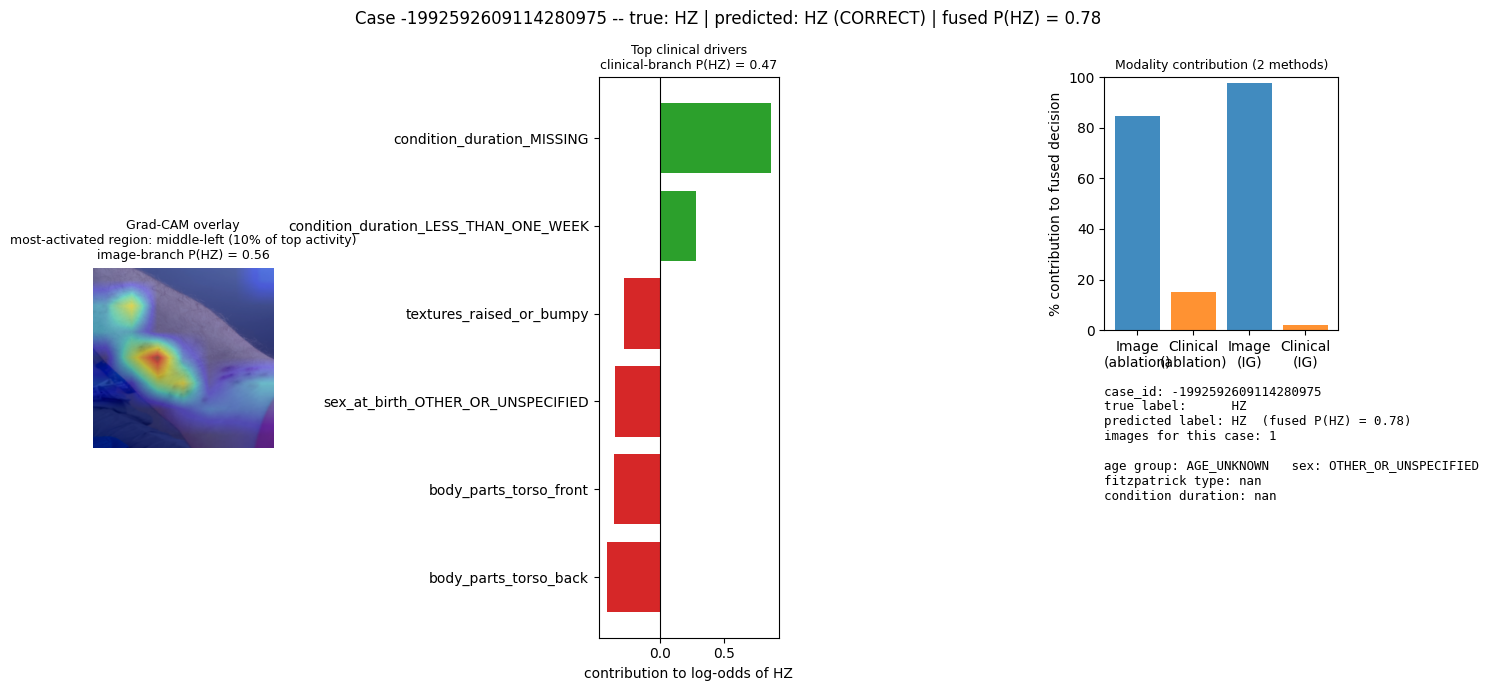

In [18]:
def explain_case(case_id, top_k_clinical=6, save=True, show=True):
    assert case_id in CASE_ROWS, f"case_id {case_id} not found in the test-set explanation table."
    c = CASE_ROWS[case_id]
    row = c["raw"]

    img, cam, img_prob = compute_gradcam(c["display_path"])
    region, coverage = localize_heatmap(cam)

    clin_df = logreg_feature_contributions(c["clin_x"], top_k=top_k_clinical)
    clin_prob = c["clin_prob"]

    fused_prob, _ = fusion_predict_proba(c["img_emb"], c["clin_emb"])
    ablation = modality_ablation(c["img_emb"], c["clin_emb"])
    ig_img_pct, ig_clin_pct = integrated_gradients_fusion(c["img_emb"], c["clin_emb"])

    pred_label = int(fused_prob >= 0.5)
    true_label = int(row["label"])
    CLS = {0: "Non-HZ", 1: "HZ"}

    fig = plt.figure(figsize=(13, 7))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.3])

    ax_img = fig.add_subplot(gs[:, 0])
    ax_img.imshow(img); ax_img.imshow(cam, cmap="jet", alpha=0.45); ax_img.axis("off")
    ax_img.set_title(f"Grad-CAM overlay\nmost-activated region: {region} ({coverage:.0%} of top activity)\n"
                      f"image-branch P(HZ) = {img_prob:.2f}", fontsize=9)

    ax_clin = fig.add_subplot(gs[:, 1])
    colors = ["#2ca02c" if v > 0 else "#d62728" for v in clin_df["contribution_logodds"]]
    ax_clin.barh(clin_df["feature"], clin_df["contribution_logodds"], color=colors)
    ax_clin.axvline(0, color="black", linewidth=0.8)
    ax_clin.set_xlabel("contribution to log-odds of HZ")
    ax_clin.set_title(f"Top clinical drivers\nclinical-branch P(HZ) = {clin_prob:.2f}", fontsize=9)

    ax_mod = fig.add_subplot(gs[0, 2])
    ax_mod.bar(["Image\n(ablation)", "Clinical\n(ablation)", "Image\n(IG)", "Clinical\n(IG)"],
               [ablation["image_share_pct"], ablation["clinical_share_pct"], ig_img_pct, ig_clin_pct],
               color=["#1f77b4", "#ff7f0e", "#1f77b4", "#ff7f0e"], alpha=0.85)
    ax_mod.set_ylabel("% contribution to fused decision")
    ax_mod.set_ylim(0, 100)
    ax_mod.set_title("Modality contribution (2 methods)", fontsize=9)

    ax_txt = fig.add_subplot(gs[1, 2]); ax_txt.axis("off")
    summary_lines = [
        f"case_id: {case_id}",
        f"true label:      {CLS[true_label]}",
        f"predicted label: {CLS[pred_label]}  (fused P(HZ) = {fused_prob:.2f})",
        f"images for this case: {c['n_images']}",
        "",
        f"age group: {row.get('age_group', 'NA')}   sex: {row.get('sex_at_birth', 'NA')}",
        f"fitzpatrick type: {row.get('fitzpatrick_skin_type', 'NA')}",
        f"condition duration: {row.get('condition_duration', 'NA')}",
    ]
    ax_txt.text(0, 1, "\n".join(summary_lines), va="top", ha="left", fontsize=9, family="monospace")

    correctness = "CORRECT" if pred_label == true_label else "INCORRECT"
    fig.suptitle(f"Case {case_id} -- true: {CLS[true_label]} | predicted: {CLS[pred_label]} "
                 f"({correctness}) | fused P(HZ) = {fused_prob:.2f}", fontsize=12)
    plt.tight_layout()
    if save:
        fig.savefig(OUT_EXPL / "cases" / f"case_{case_id}.png", dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "case_id": case_id, "true_label": true_label, "predicted_label": pred_label,
        "fused_prob": fused_prob, "image_branch_prob": img_prob, "clinical_branch_prob": clin_prob,
        "gradcam_region": region, "gradcam_coverage": coverage,
        "image_share_pct_ablation": ablation["image_share_pct"],
        "clinical_share_pct_ablation": ablation["clinical_share_pct"],
        "image_share_pct_ig": ig_img_pct, "clinical_share_pct_ig": ig_clin_pct,
        "top_clinical_feature": clin_df.iloc[-1]["feature"],
        "top_clinical_contribution": clin_df.iloc[-1]["contribution_logodds"],
    }

# Try it on the example case used for the smoke tests above.
_ = explain_case(_example_cid)

## 10. Batch explanations over representative test cases

Mirrors the correct/incorrect x HZ/Non-HZ breakdown already used for Grad-CAM in `image_model_btp.ipynb`,
but now driven by the **fused** prediction (image + clinical together), and with the full combined
dashboard from Section 9 for each case. For every available category, the highest-confidence example
is explained; a summary CSV covering **every** test case is also written.

Fused test-set confusion breakdown:
  correct_hz                         : 6 case(s)
  incorrect_hz (false negative)      : 2 case(s)
  correct_non_hz                     : 4 case(s)
  incorrect_non_hz (false positive)  : 5 case(s)

[correct_hz] explaining highest-confidence example: case -6283610000286329144


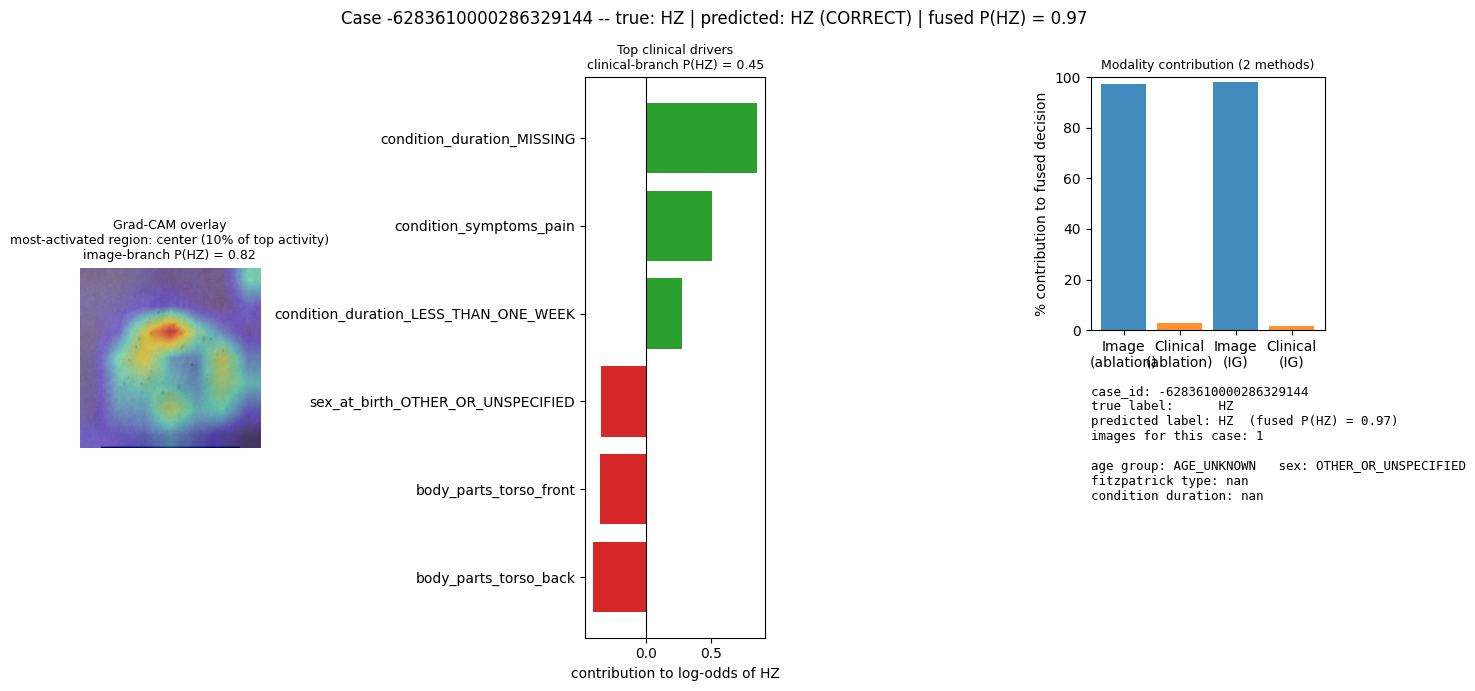


[incorrect_hz (false negative)] explaining highest-confidence example: case -4235105348901752026


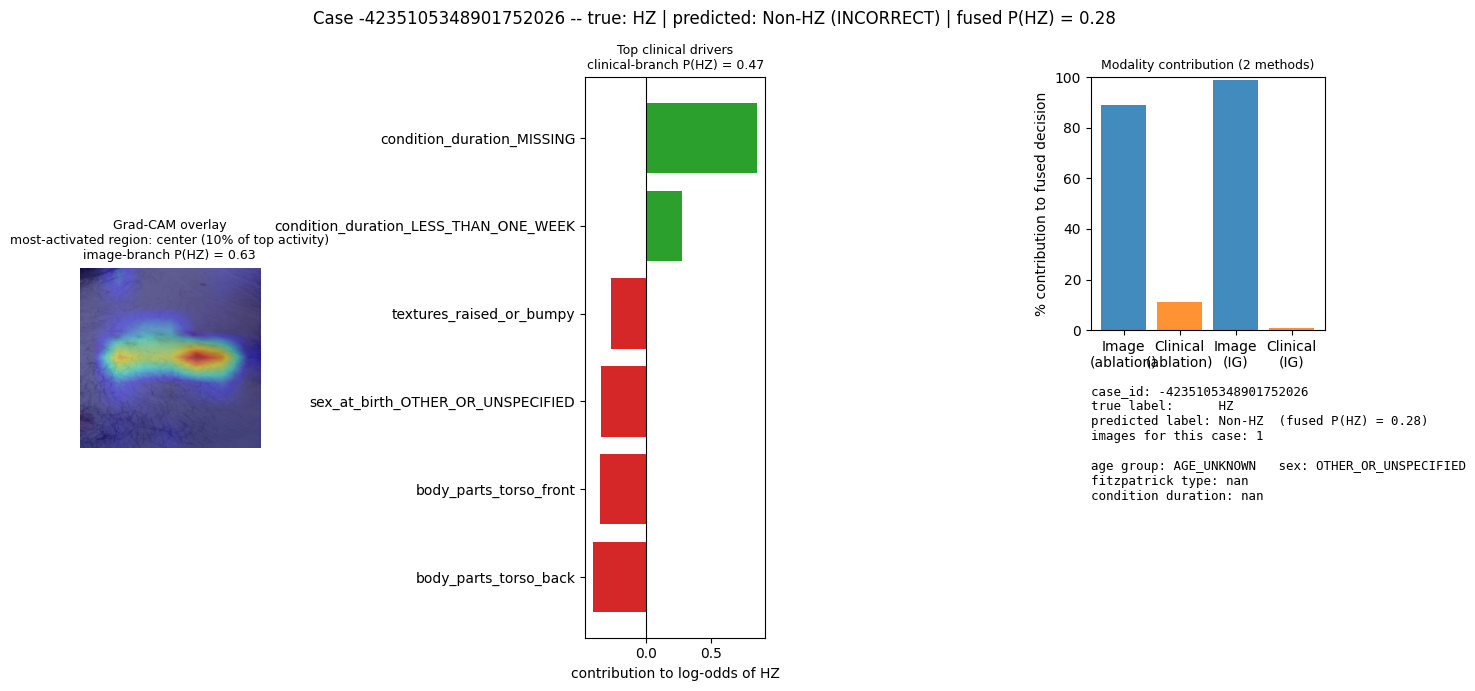


[correct_non_hz] explaining highest-confidence example: case 400823602091867105


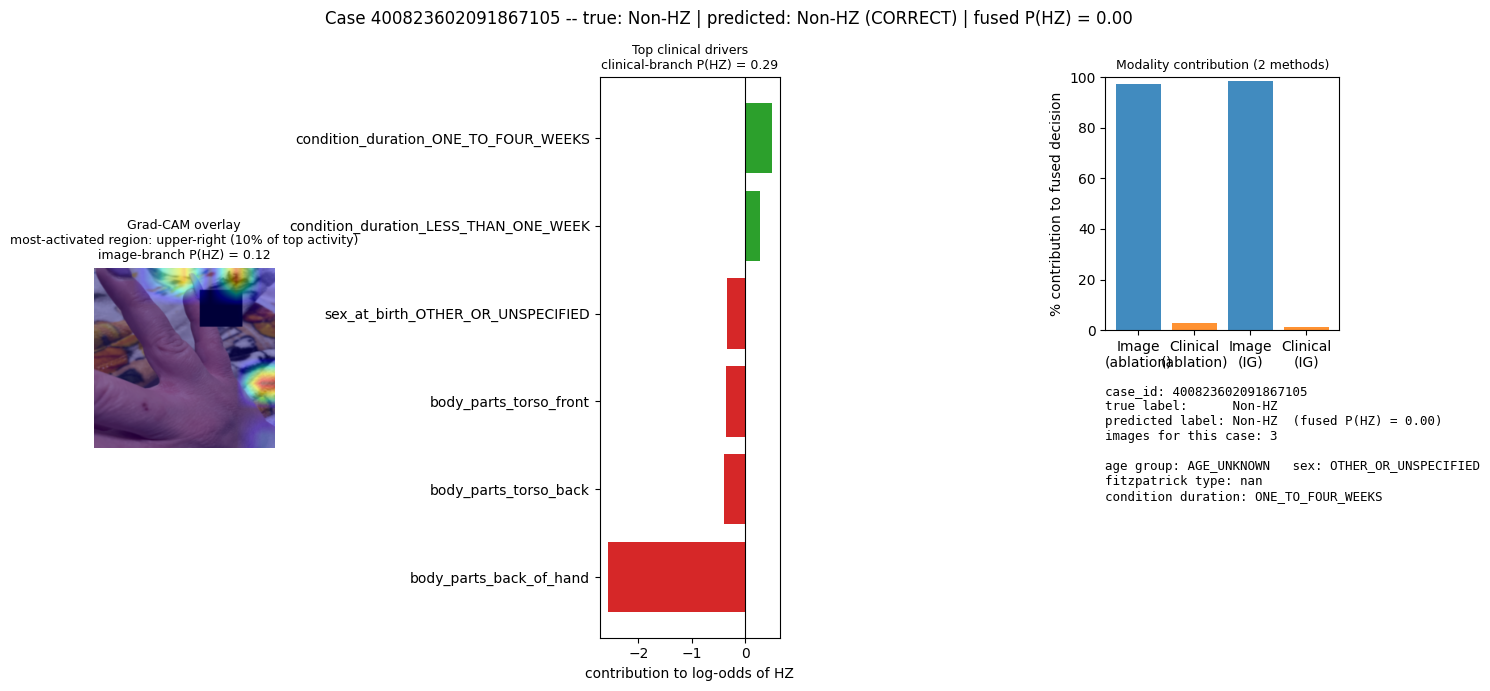


[incorrect_non_hz (false positive)] explaining highest-confidence example: case 5227299278338452921


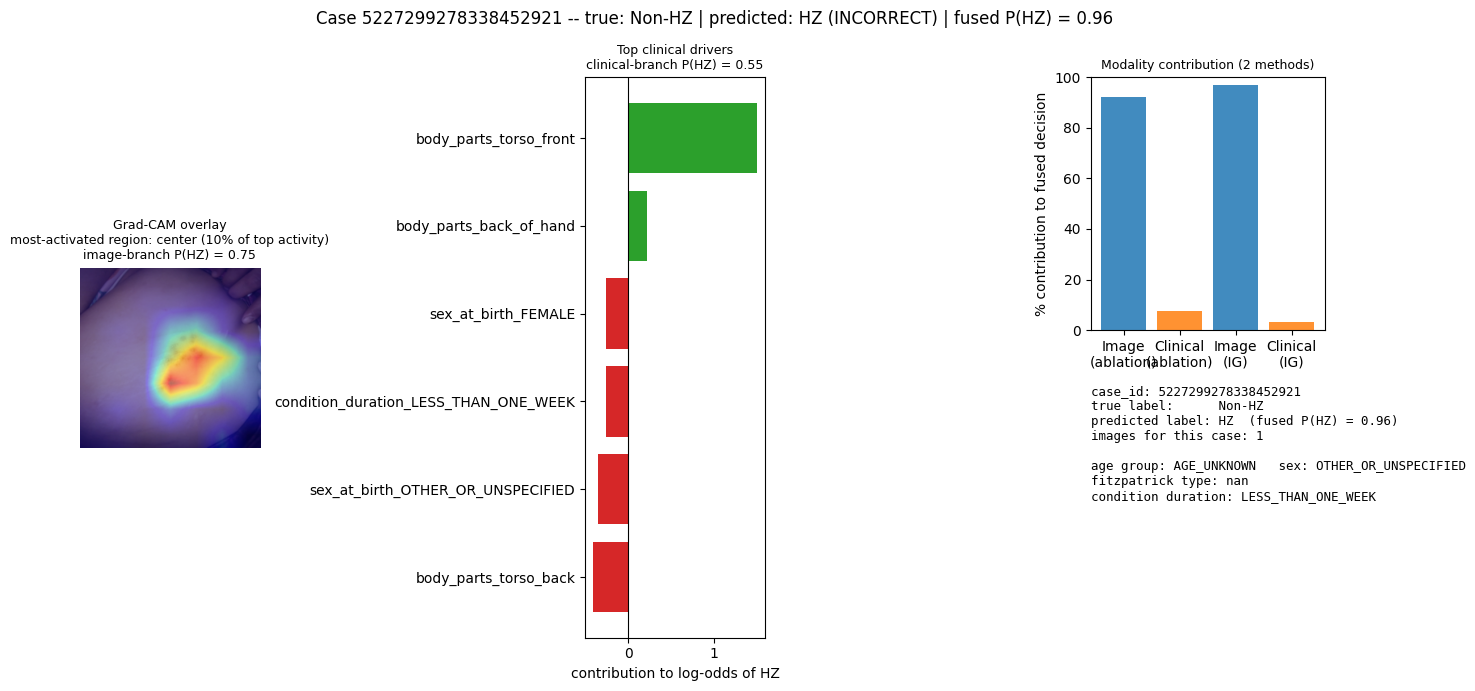


Saved 5 dashboard image(s) to outputs/explanations/cases


In [29]:
fused_probs = {cid: fusion_predict_proba(v["img_emb"], v["clin_emb"])[0] for cid, v in CASE_ROWS.items()}
fused_summary_df = pd.DataFrame([
    {"case_id": cid, "true_label": int(v["raw"]["label"]), "fused_prob": fused_probs[cid],
     "predicted_label": int(fused_probs[cid] >= 0.5)}
    for cid, v in CASE_ROWS.items()
]).astype({'case_id': object}) # Explicitly cast to object to preserve native Python ints
fused_summary_df["confidence"] = np.where(
    fused_summary_df["predicted_label"] == 1, fused_summary_df["fused_prob"], 1 - fused_summary_df["fused_prob"])

CATS = {"correct_hz": (1, 1), "incorrect_hz (false negative)": (1, 0),
        "correct_non_hz": (0, 0), "incorrect_non_hz (false positive)": (0, 1)}

print("Fused test-set confusion breakdown:")
for name, (t, p) in CATS.items():
    n = int(((fused_summary_df.true_label == t) & (fused_summary_df.predicted_label == p)).sum())
    print(f"  {name:35s}: {n} case(s)")

explanation_rows = []
for name, (t, p) in CATS.items():
    sub = fused_summary_df[(fused_summary_df.true_label == t) & (fused_summary_df.predicted_label == p)]
    sub = sub.sort_values("confidence", ascending=False)
    if sub.empty:
        print(f"\n[{name}] no test cases in this category -- skipped.")
        continue
    top_case = int(sub.iloc[0]["case_id"]) # Explicitly cast to int to ensure correct lookup
    print(f"\n[{name}] explaining highest-confidence example: case {top_case}")
    explanation_rows.append(explain_case(top_case))

print(f"\nSaved {len(list((OUT_EXPL / 'cases').glob('*.png')))} dashboard image(s) to {OUT_EXPL / 'cases'}")

In [30]:
# Full per-case summary (all test cases, not just the 4 headline examples above) -- generated
# WITHOUT plotting, so this runs quickly even for a larger test set.
all_case_rows = []
for cid in CASE_ROWS:
    all_case_rows.append(explain_case(cid, save=False, show=False))

explanation_summary_df = pd.DataFrame(all_case_rows).sort_values("case_id").reset_index(drop=True)
explanation_summary_df.to_csv(OUT_EXPL / "explanation_summary.csv", index=False)

print(f"Saved per-case explanation summary for all {len(explanation_summary_df)} test cases to "
      f"{OUT_EXPL / 'explanation_summary.csv'}")
explanation_summary_df[["case_id", "true_label", "predicted_label", "fused_prob",
                        "image_share_pct_ablation", "clinical_share_pct_ablation",
                        "top_clinical_feature"]].head(10)

Saved per-case explanation summary for all 17 test cases to outputs/explanations/explanation_summary.csv


,case_id,true_label,predicted_label,fused_prob,image_share_pct_ablation,clinical_share_pct_ablation,top_clinical_feature
0,-8888548011588959656,1,1,0.655240,82.747331,17.252668,sex_at_birth_OTHER_OR_UNSPECIFIED
1,-6283610000286329144,1,1,0.968448,97.195546,2.804454,condition_duration_MISSING
2,-4752985713674166359,1,0,0.301364,94.090220,5.909779,body_parts_back_of_hand
3,-4501267961056495678,1,1,0.829158,86.399916,13.600083,body_parts_torso_back
4,-4235105348901752026,1,0,0.276110,88.980515,11.019484,condition_duration_MISSING
5,-4059203500843188433,0,1,0.801097,92.482929,7.517070,other_symptoms_fatigue
6,-1992592609114280975,1,1,0.782116,84.806968,15.193032,condition_duration_MISSING
7,-352783143458693731,1,1,0.833985,88.726952,11.273047,age_group_AGE_40_TO_49
8,400823602091867105,0,0,0.002804,97.190249,2.809751,condition_duration_ONE_TO_FOUR_WEEKS
9,688226248701632218,1,1,0.797411,87.166013,12.833986,condition_duration_LESS_THAN_ONE_WEEK


## 11. Look up any case by ID

Use this cell to generate the full dashboard for any single test case_id (e.g. one flagged during
manual review), without re-running the whole batch above.

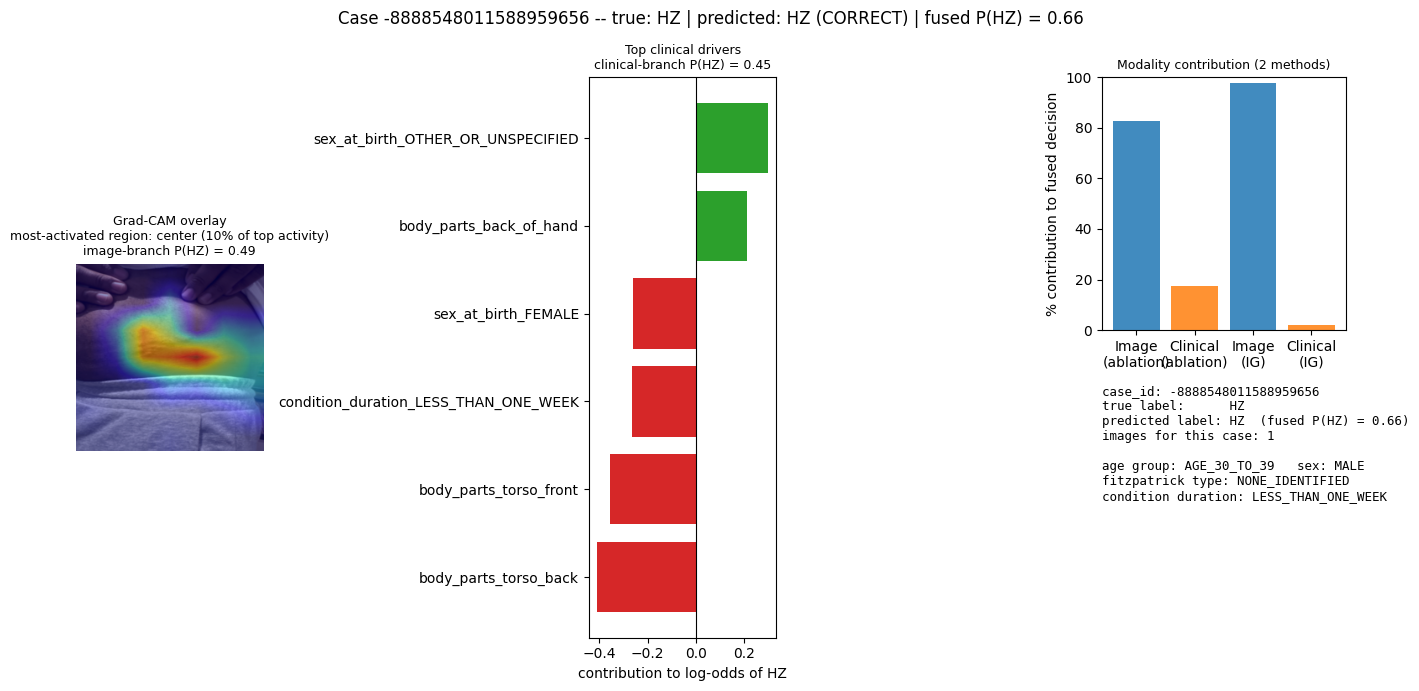

In [31]:
# Example: replace with any case_id from `explanation_summary_df["case_id"]`
example_case_id = explanation_summary_df.iloc[0]["case_id"]
_ = explain_case(example_case_id)

## 12. Limitations and interpretation

- **Sample size.** The test set has only 17 cases, so per-category examples in Section 10 (and any
  individual case's explanation) should be read as **illustrative**, not as a statistically reliable
  characterization of the model's general behaviour.
- **Grad-CAM caveats.** Heatmaps show which spatial regions of the CNN's last convolutional block most
  influenced the HZ logit; they are a visual aid and do **not** prove the model is keying on clinically
  meaningful features (e.g. vesicles, dermatomal distribution) rather than incidental correlates (lighting,
  framing, skin tone, background).
- **Attribution method (dis)agreement.** The clinical branch is explained by two different methods
  (exact logistic-regression decomposition and Integrated Gradients on the MLP); the fusion branch is
  explained by two different methods (ablation and Integrated Gradients). Where the two methods disagree
  for a given case, treat that case's explanation with extra caution rather than trusting either method
  in isolation.
- **Ablation baseline choice.** "Removing" a modality is defined here as replacing its embedding with
  the training-set mean embedding, not literally omitting it (the fusion model was never trained without
  both inputs present) -- this is a common and reasonable approximation, but it is still an approximation.
- **Modality attribution.** The image/clinical percentages are relative attribution measures under the specified ablation and Integrated Gradients baselines; they are not causal percentages or proof that one modality "caused" the prediction.
- **Framing.** This is a research / decision-support prototype exploring explainability for a small,
  fused clinical + image classifier, **not a diagnostic tool**, and none of its outputs (predictions,
  heatmaps, or feature attributions) should be used to make real clinical decisions.